In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def make_temperature_field(x, y):
    room_temperature = 26.0

    machine_heat = 6.0 * np.exp(
        -(((x - 7.5) ** 2) / 2.0 + ((y - 2.0) ** 2) / 1.5)
    )

    air_conditioner = 4.0 * np.exp(
        -(((x - 1.0) ** 2) / 3.0 + ((y - 6.5) ** 2) / 2.0)
    )

    airflow = 0.4 * np.sin(np.pi * x / 5) * np.cos(np.pi * y / 4)

    return room_temperature + machine_heat - air_conditioner + airflow

In [3]:
test_temperature = make_temperature_field(7.5, 2.0)
print(f"Temperature near the machine: {test_temperature:.1f} °C")

Temperature near the machine: 32.0 °C


In [4]:
x = np.linspace(0, 10, 200)
y = np.linspace(0, 8, 160)

In [6]:
x.shape

(200,)

In [7]:
y.shape

(160,)

In [8]:
x

array([ 0.        ,  0.05025126,  0.10050251,  0.15075377,  0.20100503,
        0.25125628,  0.30150754,  0.35175879,  0.40201005,  0.45226131,
        0.50251256,  0.55276382,  0.60301508,  0.65326633,  0.70351759,
        0.75376884,  0.8040201 ,  0.85427136,  0.90452261,  0.95477387,
        1.00502513,  1.05527638,  1.10552764,  1.15577889,  1.20603015,
        1.25628141,  1.30653266,  1.35678392,  1.40703518,  1.45728643,
        1.50753769,  1.55778894,  1.6080402 ,  1.65829146,  1.70854271,
        1.75879397,  1.80904523,  1.85929648,  1.90954774,  1.95979899,
        2.01005025,  2.06030151,  2.11055276,  2.16080402,  2.21105528,
        2.26130653,  2.31155779,  2.36180905,  2.4120603 ,  2.46231156,
        2.51256281,  2.56281407,  2.61306533,  2.66331658,  2.71356784,
        2.7638191 ,  2.81407035,  2.86432161,  2.91457286,  2.96482412,
        3.01507538,  3.06532663,  3.11557789,  3.16582915,  3.2160804 ,
        3.26633166,  3.31658291,  3.36683417,  3.41708543,  3.46

In [9]:
X, Y = np.meshgrid(x, y)

In [10]:
X.shape

(160, 200)

In [11]:
Y.shape

(160, 200)

In [12]:
temperature = make_temperature_field(X, Y)

print("Grid shape:", temperature.shape)
print("Minimum:", temperature.min())
print("Maximum:", temperature.max())

Grid shape: (160, 200)
Minimum: 22.086392153637643
Maximum: 32.003476271985704


In [13]:
sensor_positions = np.array([
    [1, 1], [3, 2], [5, 1], [8, 1],
    [2, 4], [5, 4], [8, 4],
    [1, 7], [4, 7], [7, 7], [9, 7],
])

In [14]:
sensor_x = sensor_positions[:, 0]
sensor_y = sensor_positions[:, 1]

sensor_values = make_temperature_field(sensor_x, sensor_y)

In [15]:
print("Grid shape:", sensor_values.shape)
print("Minimum:", sensor_values.min())
print("Maximum:", sensor_values.max())

Grid shape: (11,)
Minimum: 22.6362631647726
Maximum: 28.449534698895345


In [16]:
rng = np.random.default_rng(42)
sensor_values += rng.normal(0, 0.15, len(sensor_positions))

In [17]:
def format_room_axes(ax, title):
    ax.set(
        title=title,
        xlabel="Room width (m)",
        ylabel="Room height (m)",
        xlim=(0, 10),
        ylim=(0, 8),
        aspect="equal",
    )

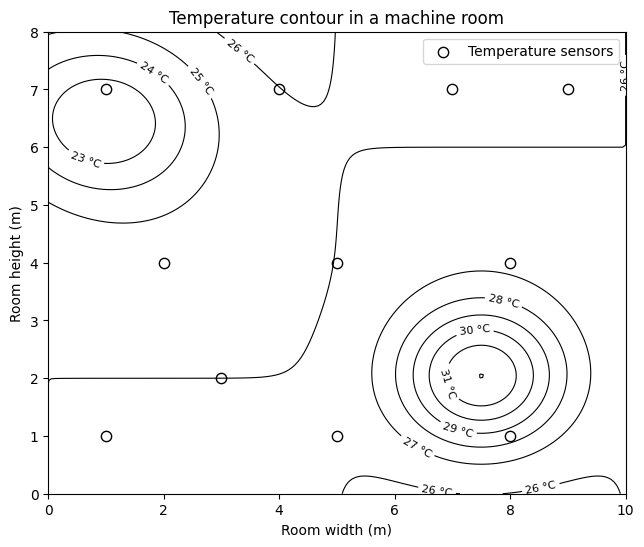

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

levels = np.arange(22, 34, 1)
lines = ax.contour(
    X, Y, temperature,
    levels=levels,
    colors="black",
    linewidths=0.8,
)
ax.clabel(lines, inline=True, fontsize=8, fmt="%.0f °C")

ax.scatter(
    sensor_x, sensor_y,
    color="white",
    edgecolor="black",
    s=55,
    label="Temperature sensors",
)

format_room_axes(ax, "Temperature contour in a machine room")
ax.legend()
plt.show()

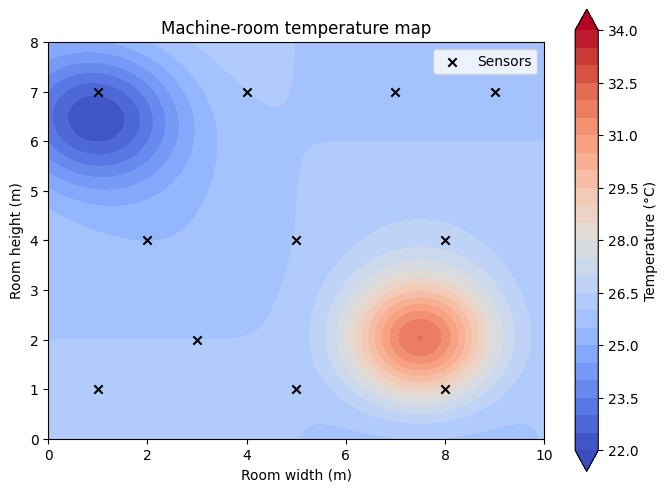

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

color_levels = np.arange(22, 34.5, 0.5)
filled = ax.contourf(
    X, Y, temperature,
    levels=color_levels,
    cmap="coolwarm",
    extend="both",
)

fig.colorbar(filled, ax=ax, label="Temperature (°C)")
ax.scatter(
    sensor_x, sensor_y,
    color="black",
    marker="x",
    label="Sensors",
)

format_room_axes(ax, "Machine-room temperature map")
ax.legend()
plt.show()

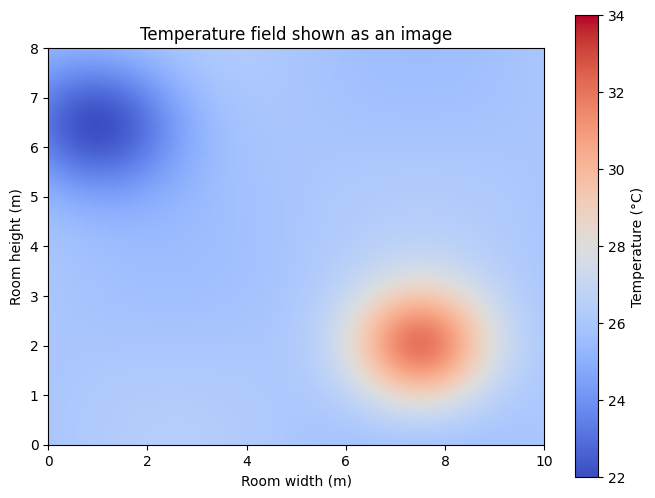

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(
    temperature,
    extent=[0, 10, 0, 8],
    origin="lower",
    cmap="coolwarm",
    vmin=22,
    vmax=34,
    aspect="equal",
)

fig.colorbar(image, ax=ax, label="Temperature (°C)")
format_room_axes(ax, "Temperature field shown as an image")
plt.show()

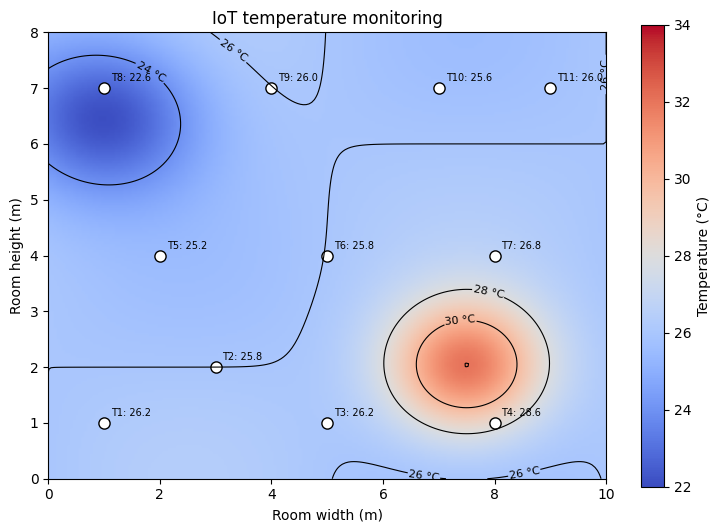

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))

image = ax.imshow(
    temperature,
    extent=[0, 10, 0, 8],
    origin="lower",
    cmap="coolwarm",
    vmin=22,
    vmax=34,
    aspect="equal",
)

lines = ax.contour(
    X, Y, temperature,
    levels=[24, 26, 28, 30, 32],
    colors="black",
    linewidths=0.8,
)
ax.clabel(lines, inline=True, fontsize=8, fmt="%.0f °C")

ax.scatter(
    sensor_x, sensor_y,
    color="white",
    edgecolor="black",
    s=65,
)

for index, ((x_pos, y_pos), value) in enumerate(
    zip(sensor_positions, sensor_values),
    start=1,
):
    ax.annotate(
        f"T{index}: {value:.1f}",
        (x_pos, y_pos),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7,
    )

fig.colorbar(image, ax=ax, label="Temperature (°C)")
format_room_axes(ax, "IoT temperature monitoring")
plt.show()